# All the necessary imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("✅ All libraries imported successfully!\n")

✅ All libraries imported successfully!



Loading the data in this cell

In [42]:
os.chdir(r"C:\Users\OLUYEMI\Documents\GitHub\folakay") 
data_path = "data/"
print("New working directory:", os.getcwd())



"""   
ass = 'assessments.csv' # Contains the details about the assessments - tests, projects and exams
cou = 'courses.csv' # Contains details about the courses
sam = 'sample_studentVle.csv' # A small sample of the vle just for tetsing. 5000 entries
stdass = 'studentAssessment.csv' # Contains details of the asssessment records of the students
std = 'studentInfo.csv' # Personal details of the students
stdreg = 'studentRegistration.csv' # Linking students to the courses and assessments
vle_file = 'vle.csv' # Don't really know what this file does.

"""

print("Loading data...")

vle = pd.read_csv(os.path.join(data_path, "studentVle.csv"), low_memory=True)
ass = pd.read_csv(os.path.join(data_path, "assessments.csv"), low_memory=True)
cou = pd.read_csv(os.path.join(data_path, "courses.csv"), low_memory=True)
# sam = pd.read_csv(os.path.join(data_path, "sample_studentVle.csv"), low_memory=True)
stdass = pd.read_csv(os.path.join(data_path, "studentAssessment.csv"), low_memory=True)
std = pd.read_csv(os.path.join(data_path, "studentInfo.csv"), low_memory=True)
stdreg = pd.read_csv(os.path.join(data_path, "studentRegistration.csv"), low_memory=True)
vle_file = pd.read_csv(os.path.join(data_path, "vle.csv"), low_memory=True)

New working directory: C:\Users\OLUYEMI\Documents\GitHub\folakay
Loading data...


## VLE FILE - Contains the students' VLE

In [3]:
vle_file.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,?,?
1,546712,AAA,2013J,oucontent,?,?
2,546998,AAA,2013J,resource,?,?
3,546888,AAA,2013J,url,?,?
4,547035,AAA,2013J,resource,?,?


In [4]:
vle_file.describe(include='all')

,id_site,code_module,code_presentation,activity_type,week_from,week_to
count,6.364000e+03,6364,6364,6364,6364,6364
unique,NaN,7,4,20,31,31
top,NaN,FFF,2013J,resource,?,?
freq,NaN,1967,1772,2660,5243,5243
mean,7.260991e+05,NaN,NaN,NaN,NaN,NaN
std,1.283151e+05,NaN,NaN,NaN,NaN,NaN
min,5.267210e+05,NaN,NaN,NaN,NaN,NaN
25%,6.615928e+05,NaN,NaN,NaN,NaN,NaN
50%,7.300965e+05,NaN,NaN,NaN,NaN,NaN
75%,8.140162e+05,NaN,NaN,NaN,NaN,NaN


It seems the week from and week to are unidentified characters.

In [5]:
display(vle_file[['week_from', 'week_to']].describe())

display(vle_file[['week_from', 'week_to']].info())

display(vle_file['week_from'].unique())

display(vle_file['week_to'].unique())

,week_from,week_to
count,6364,6364
unique,31,31
top,?,?
freq,5243,5243


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   week_from  6364 non-null   object
 1   week_to    6364 non-null   object
dtypes: object(2)
memory usage: 99.6+ KB


None

array(['?', '2', '1', '9', '11', '22', '6', '8', '19', '4', '15', '14',
       '25', '20', '27', '16', '24', '3', '21', '18', '26', '10', '5',
       '28', '23', '13', '12', '7', '17', '0', '29'], dtype=object)

array(['?', '2', '1', '9', '11', '22', '6', '8', '19', '4', '15', '14',
       '25', '20', '27', '16', '24', '3', '21', '18', '26', '10', '5',
       '28', '23', '13', '12', '7', '17', '0', '29'], dtype=object)

Most of the courses have their week_from and week_to as unknown values

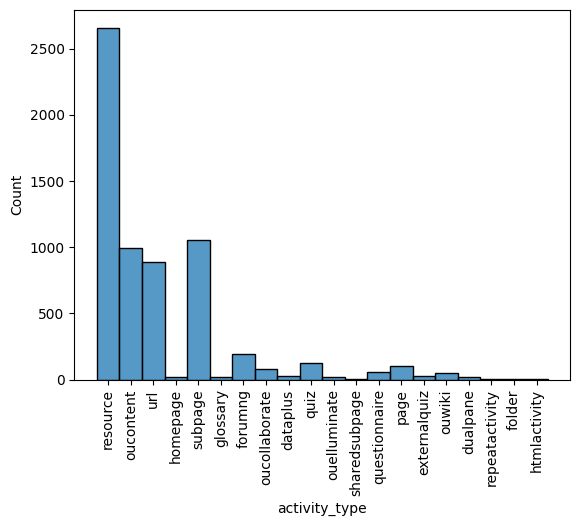

In [6]:
sns.histplot(vle_file, x='activity_type')
plt.xticks(rotation=90)
plt.show()

## ASSESSMENT - Contains details about the assessments

In [7]:
display(ass.head())

ass.shape


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19,10.0
1,AAA,2013J,1753,TMA,54,20.0
2,AAA,2013J,1754,TMA,117,20.0
3,AAA,2013J,1755,TMA,166,20.0
4,AAA,2013J,1756,TMA,215,30.0


(206, 6)

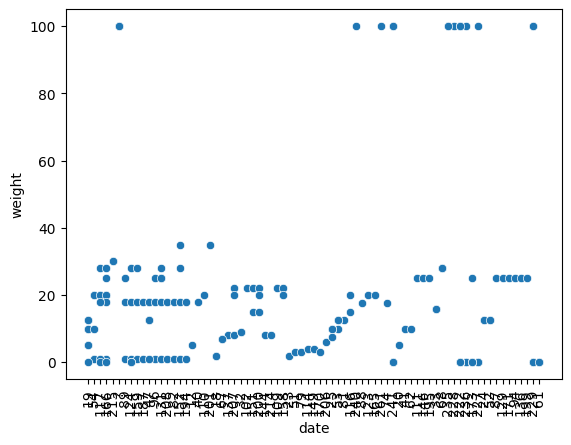

In [13]:
sns.scatterplot(data=ass, x='date', y='weight')
plt.xticks(None, rotation=90)
plt.show()

There is no definite relationship between the number of days the assessment takes before it is required to be handed in and the weight of the assessment.

## COURSES - Information about the courses

In [14]:
display(cou.head())

display(cou.shape)

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


(22, 3)

This is just a list of 22 courses and their details

## STUDENT ASSESSMENT - Assessment records of each student

In [15]:
stdass.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78
1,1752,28400,22,0,70
2,1752,31604,17,0,72
3,1752,32885,26,0,69
4,1752,38053,19,0,79


The ```is_banked``` column is stating whether the assessment result is transferred from a previous course.

In [17]:
stdass['is_banked'].describe(include='all')

count    173912.000000
mean          0.010977
std           0.104194
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: is_banked, dtype: float64

In [18]:
stdass.shape

(173912, 5)

## STUDENT INFO - Individual details of the students

In [19]:
display(std.head())

display(std.shape)

std.describe(include='all')

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


(32593, 12)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
count,32593,32593,3.259300e+04,32593,32593,32593,32593,32593,32593.000000,32593.000000,32593,32593
unique,7,4,NaN,2,13,5,11,3,NaN,NaN,2,4
top,BBB,2014J,NaN,M,Scotland,A Level or Equivalent,20-30%,0-35,NaN,NaN,N,Pass
freq,7909,11260,NaN,17875,3446,14045,3654,22944,NaN,NaN,29429,12361
mean,NaN,NaN,7.066877e+05,NaN,NaN,NaN,NaN,NaN,0.163225,79.758691,NaN,NaN
std,NaN,NaN,5.491673e+05,NaN,NaN,NaN,NaN,NaN,0.479758,41.071900,NaN,NaN
min,NaN,NaN,3.733000e+03,NaN,NaN,NaN,NaN,NaN,0.000000,30.000000,NaN,NaN
25%,NaN,NaN,5.085730e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN
50%,NaN,NaN,5.903100e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN
75%,NaN,NaN,6.444530e+05,NaN,NaN,NaN,NaN,NaN,0.000000,120.000000,NaN,NaN


The datacard says the ```imd_band``` means the ```Index of Multiple Depravation``` of the region in which the student resided while taking the course. I do not know what that means. If you do, write it here.

## STUDENT REGISTRATION - Regirstration information of the students

In [20]:
stdreg.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159,?
1,AAA,2013J,28400,-53,?
2,AAA,2013J,30268,-92,12
3,AAA,2013J,31604,-52,?
4,AAA,2013J,32885,-176,?


In [21]:
stdreg.shape

(32593, 5)

This file just contains the details about the registration of the students

## STUDENT VLE - Let's look inside

In [22]:
vle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [23]:
vle.shape

(10655280, 6)

In [24]:
# Filter to smallest course for speed
vle = vle[(vle["code_module"] == "AAA") & (vle["code_presentation"] == "2013J")]
print(f"✅ Loaded {len(vle):,} interaction rows for AAA-2013J")

# Load supporting file
info = pd.read_csv(os.path.join(data_path, "studentInfo.csv"))
print(f"✅ Loaded {len(info):,} student records")

# Quick preview
print("\n=== SAMPLE OF INTERACTION LOGS ===")
print(vle.head(5))

print("\n=== BASIC STATS ===")
print(vle.describe())

✅ Loaded 180,982 interaction rows for AAA-2013J
✅ Loaded 32,593 student records

=== SAMPLE OF INTERACTION LOGS ===
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1

=== BASIC STATS ===
         id_student        id_site           date      sum_click
count  1.809820e+05  180982.000000  180982.000000  180982.000000
mean   1.101693e+06  546707.875733     105.588462       3.583196
std    9.996356e+05     101.895100      80.249132       5.577962
min    1.139100e+04  546614.000000     -10.000000       1.000000
25%    2.380070e+05  546650.000000      29.000000       1.000000
50%    4.894550e+05  546660.000000     103.000000    

✅ Saved quick sample → data/sample_studentVle.csv


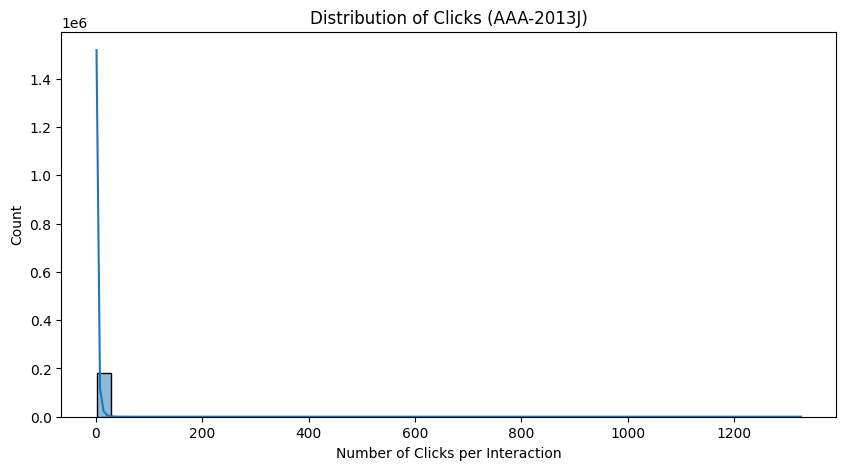


🎉 DAY 1 SUCCESS! Everything is set up and data is ready.


In [25]:
# Save tiny sample for quick testing
sample = vle.sample(5000, random_state=42)
sample.to_csv("data/sample_studentVle.csv", index=False)
print("✅ Saved quick sample → data/sample_studentVle.csv")

# Simple plot
plt.figure(figsize=(10, 5))
sns.histplot(vle["sum_click"], bins=50, kde=True)
plt.title("Distribution of Clicks (AAA-2013J)")
plt.xlabel("Number of Clicks per Interaction")
plt.show()

print("\n🎉 DAY 1 SUCCESS! Everything is set up and data is ready.")